# Análisis exploratorio de los datos

In [1]:
import os
import pandas as pd
import numpy as np

import seaborn as sns
import matplotlib.pyplot as plt

%matplotlib inline

In [2]:
# Constantes
ROOT = "../"
DATA = os.path.join(ROOT, "data")

In [3]:
# Lectura del dataset
transactions = pd.read_csv(f"{DATA}/dataset.csv")
transactions.head(3)

,a,b,c,d,e,f,g,h,j,k,l,m,n,o,p,fecha,monto,score,fraude
0,4,0.6812,50084.12,50.0,0.000000,20.0,AR,1,cat_d26ab52,0.365475,2479.0,952.0,1,NaN,Y,2020-03-20 09:28:19,57.63,100,0
1,4,0.6694,66005.49,0.0,0.000000,2.0,AR,1,cat_ea962fb,0.612728,2603.0,105.0,1,Y,Y,2020-03-09 13:58:28,40.19,25,0
2,4,0.4718,7059.05,4.0,0.463488,92.0,BR,25,cat_4c2544e,0.651835,2153.0,249.0,1,Y,Y,2020-04-08 12:25:55,5.77,23,0


In [4]:
# Analisis de calidad del dataset
transactions.info()

<class 'pandas.DataFrame'>
RangeIndex: 150000 entries, 0 to 149999
Data columns (total 19 columns):
 #   Column  Non-Null Count   Dtype  
---  ------  --------------   -----  
 0   a       150000 non-null  int64  
 1   b       137016 non-null  float64
 2   c       137016 non-null  float64
 3   d       149635 non-null  float64
 4   e       150000 non-null  float64
 5   f       149989 non-null  float64
 6   g       149806 non-null  str    
 7   h       150000 non-null  int64  
 8   j       150000 non-null  str    
 9   k       150000 non-null  float64
 10  l       149989 non-null  float64
 11  m       149635 non-null  float64
 12  n       150000 non-null  int64  
 13  o       41143 non-null   str    
 14  p       150000 non-null  str    
 15  fecha   150000 non-null  str    
 16  monto   150000 non-null  float64
 17  score   150000 non-null  int64  
 18  fraude  150000 non-null  int64  
dtypes: float64(9), int64(5), str(5)
memory usage: 21.7 MB


In [5]:
print(f"Cantidad de variables numéricas: {transactions.select_dtypes(include='number').shape[1]}")
print(f"Cantidad de variables categóricas: {transactions.select_dtypes(include='str').shape[1]}")

Cantidad de variables numéricas: 14
Cantidad de variables categóricas: 5


In [6]:
# Valores faltantes
null_summary = pd.DataFrame({
    'columna': transactions.columns,
    'cantidad faltantes': transactions.isna().sum().values,
    'porcentaje faltantes': (transactions.isna().sum().values / len(transactions)) * 100
})

null_summary = null_summary.sort_values(by='cantidad faltantes', ascending=False).reset_index(drop=True)

# Formatear el porcentaje a 2 decimales para mejor lectura en el notebook
null_summary['porcentaje faltantes'] = null_summary['porcentaje faltantes'].round(2)

# Mostrar solo las columnas que tienen al menos 1 nulo
null_summary_filtered = null_summary[null_summary['cantidad faltantes'] > 0]
null_summary_filtered

,columna,cantidad faltantes,porcentaje faltantes
0,o,108857,72.57
1,c,12984,8.66
2,b,12984,8.66
3,d,365,0.24
4,m,365,0.24
5,g,194,0.13
6,f,11,0.01
7,l,11,0.01


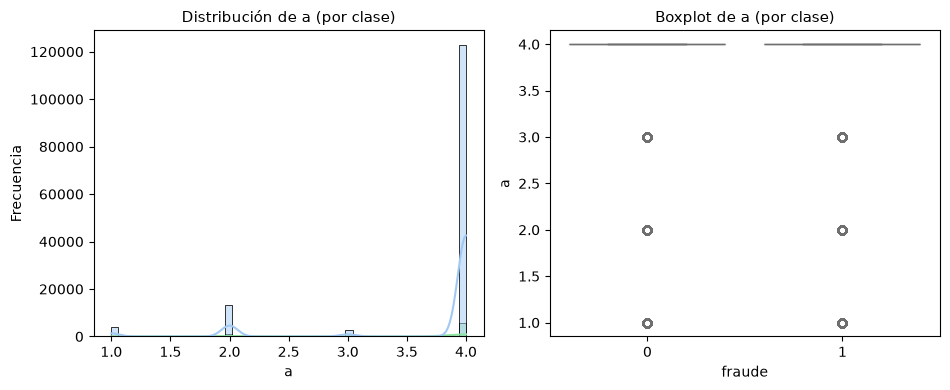

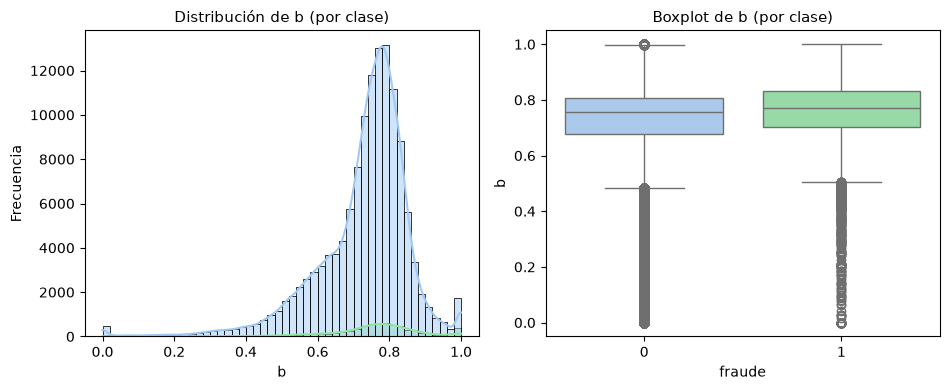

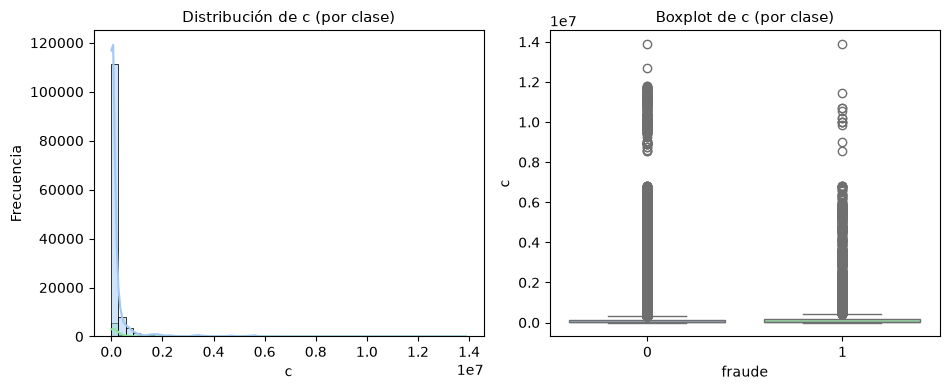

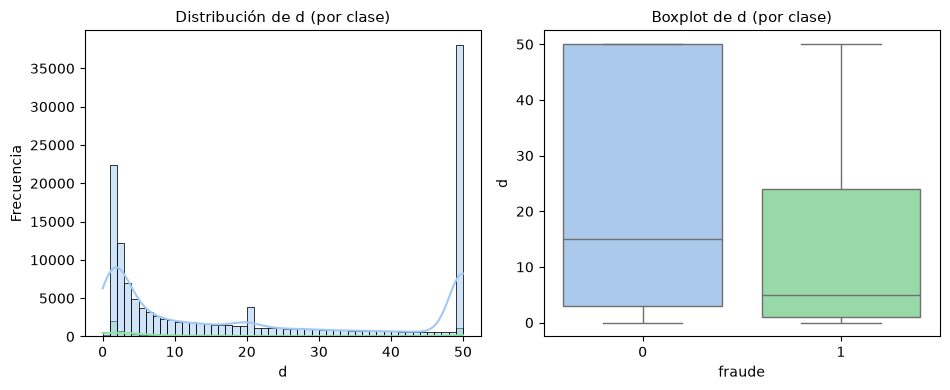

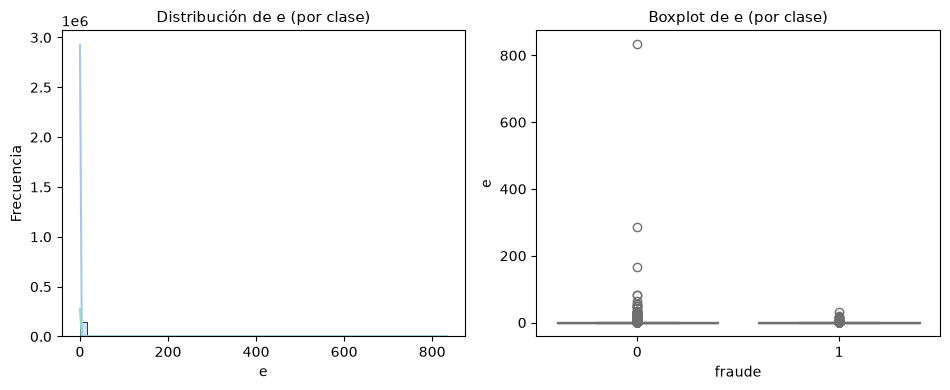

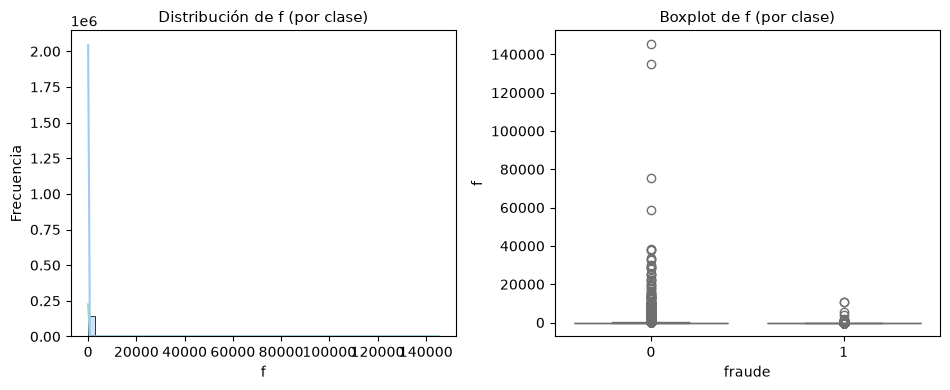

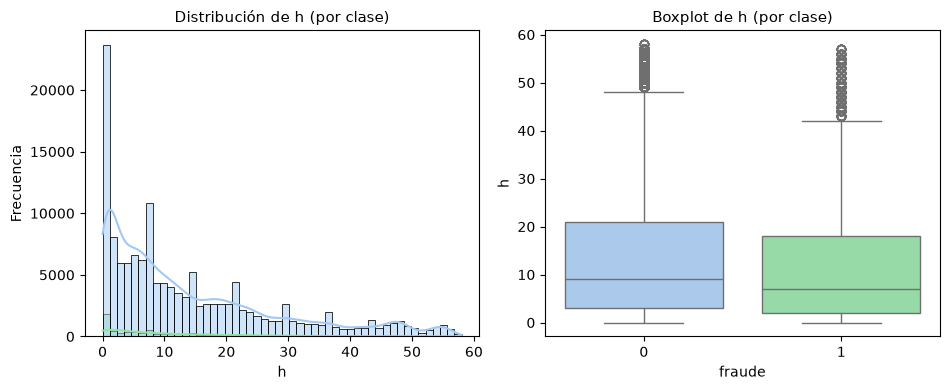

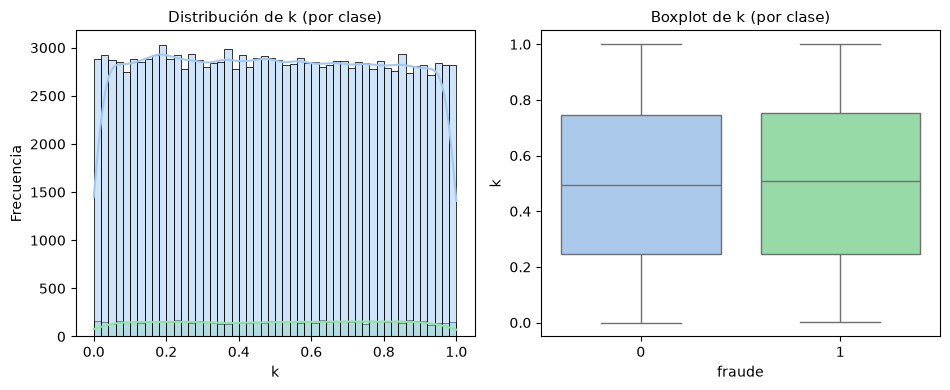

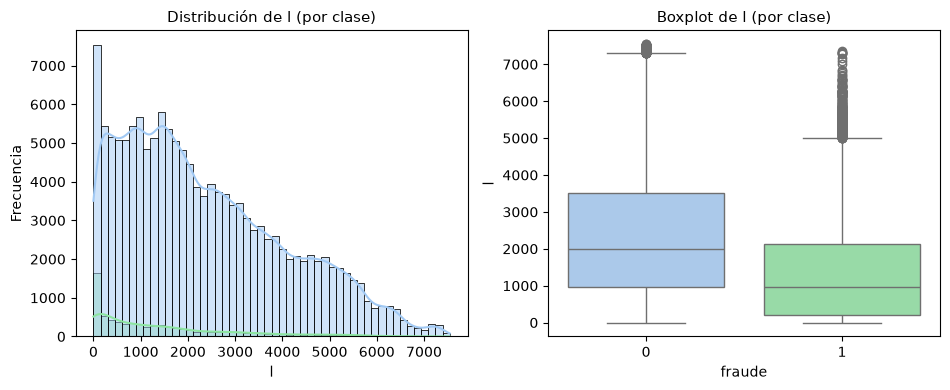

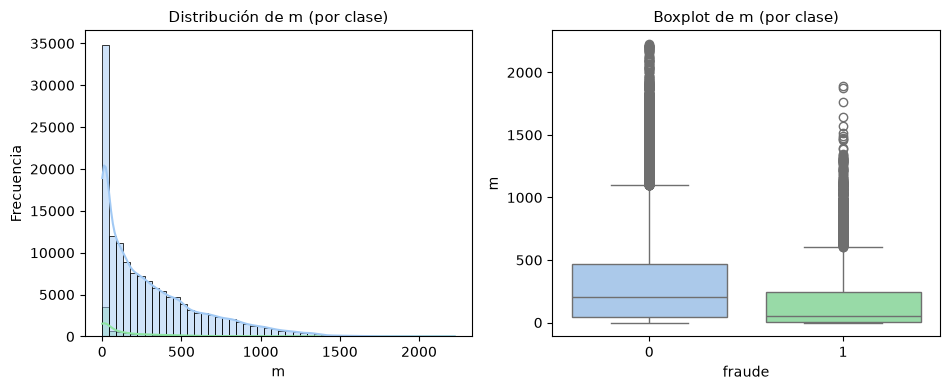

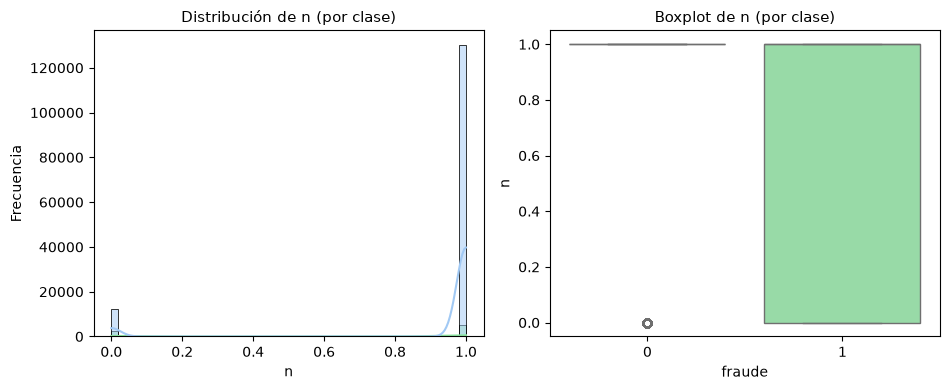

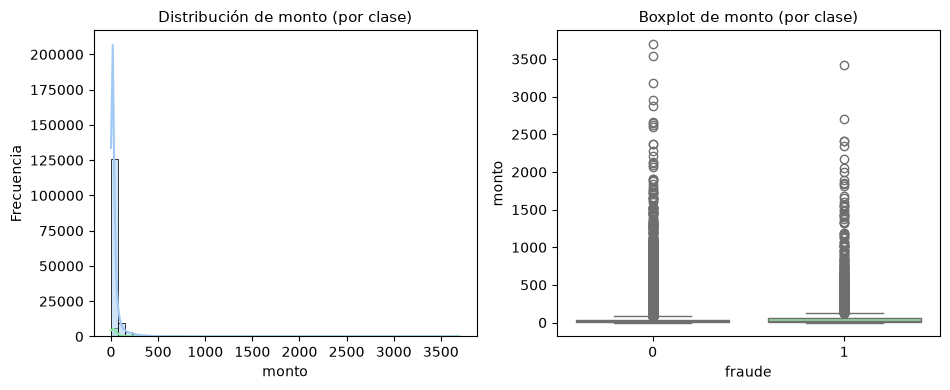

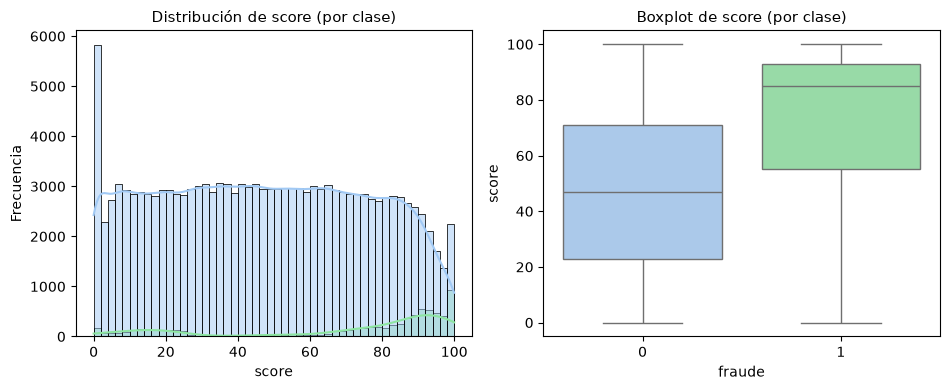

In [ ]:
# Seleccionar solo variables numéricas
num_cols = transactions.select_dtypes(include=['int64', 'float64']).columns
target_col = 'fraude'

if target_col in num_cols:
    num_cols = num_cols.drop(target_col)

for col in num_cols:
    fig, axes = plt.subplots(1, 2, figsize=(12, 4))

    # 1. Histograma (Distribución y sesgo)
    sns.histplot(data=transactions, x=col, hue=target_col, kde=True, bins=50, ax=axes[0], palette='pastel6')
    axes[0].set_title(f'Distribución de {col} (por clase)', size=11)
    axes[0].set_xlabel(col, size=10)
    axes[0].set_ylabel('Frecuencia', size=10)

    # 2. Boxplot (Detección de outliers)
    sns.boxplot(data=transactions, y=col, x=target_col, ax=axes[1], hue=target_col, palette='pastel6')
    axes[1].set_title(f'Boxplot de {col} (por clase)', size=11)
    axes[1].set_xlabel(target_col, size=10)
    axes[1].set_ylabel(col, size=10)

    # Eliminar las leyendas automáticas de cada eje
    for ax in axes:
        legend = ax.get_legend()
        if legend is not None:
            legend.remove()

    # Crear una leyenda única con los valores del target
    target_values = sorted(transactions[target_col].dropna().unique().tolist())
    colors = dict(zip(target_values, sns.color_palette('pastel6', n_colors=len(target_values))))

    handles = [
        plt.Line2D([0], [0], linestyle='None', marker='o', markersize=7, markerfacecolor=colors[val], markeredgecolor='none', label=str(val))
        for val in target_values
    ]

    fig.subplots_adjust(right=0.82)
    fig.legend(handles=handles, title=target_col, loc='center left', bbox_to_anchor=(0.84, 0.5), frameon=False, fontsize=9)

    plt.tight_layout(rect=[0, 0, 0.8, 1])
    plt.show()

⚠️ Se omitió 'g' por tener alta cardinalidad (51 valores únicos).
⚠️ Se omitió 'j' por tener alta cardinalidad (8324 valores únicos).


/var/folders/rq/q0gd7qms1wl7v17bxq5xqq240000gn/T/ipykernel_71365/3179585525.py:2: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  cat_cols = transactions.select_dtypes(include=['object', 'category', 'bool']).columns


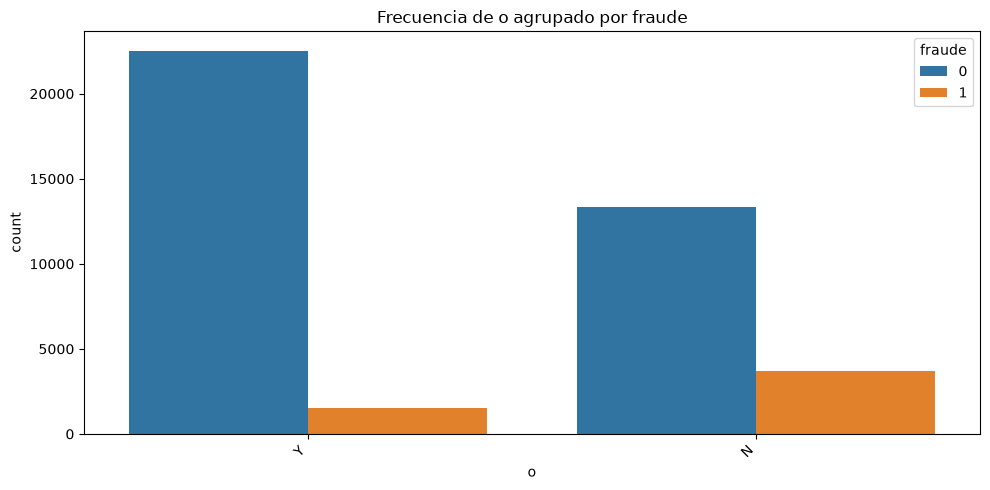

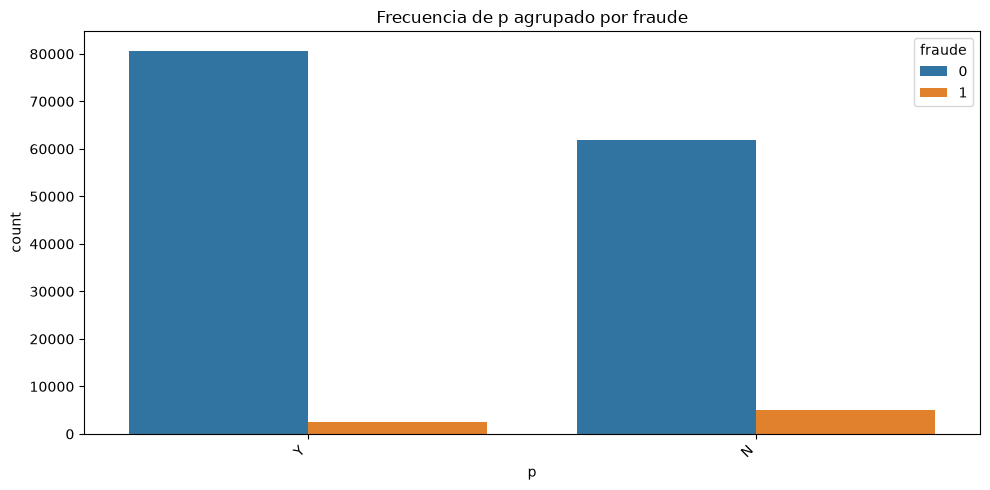

⚠️ Se omitió 'fecha' por tener alta cardinalidad (145813 valores únicos).


In [8]:
# Seleccionar variables categóricas
cat_cols = transactions.select_dtypes(include=['object', 'category', 'bool']).columns

for col in cat_cols:
    # Evitar graficar variables con demasiadas categorías (alta cardinalidad como IDs)
    if transactions[col].nunique() < 20:
        plt.figure(figsize=(10, 5))
        
        # Gráfico de barras agrupado por el target
        sns.countplot(data=transactions, x=col, hue=target_col, order=transactions[col].value_counts().index)
        
        plt.title(f'Frecuencia de {col} agrupado por {target_col}')
        plt.xticks(rotation=45, ha='right') # Rota las etiquetas si son muy largas
        plt.tight_layout()
        plt.show()
    else:
        print(f"⚠️ Se omitió '{col}' por tener alta cardinalidad ({transactions[col].nunique()} valores únicos).")